In [68]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.utils.preprocess import feature_engineering, SCALER_DICT_PATH

from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score

In [2]:
scalers = joblib.load(SCALER_DICT_PATH)
test_df, _ = feature_engineering(pd.read_csv(os.path.join("..", "data", "test.csv")), scalers=scalers)
train_df, _ = feature_engineering(pd.read_csv(os.path.join("..", "data", "train.csv")), scalers=scalers)

In [3]:
X_train, _, y_train, _ = train_test_split(train_df.drop(columns=["Value"]), train_df["Value"], random_state=42)
X_test, _, y_test, _ = train_test_split(test_df.drop(columns=["Value"]), test_df["Value"], random_state=42)

In [4]:
param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5, 7, 9, 15],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.3]
}

In [5]:
xgb_model = XGBRegressor(tree_method='hist',  enable_categorical=True, eval_metric='rmse')
# xgb_model = XGBRegressor(tree_method='exact',  enable_categorical=False, eval_metric='rmse')

grid_search = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [6]:
print(f"Optimal: {grid_search.best_params_}")
print(f"RMSE: {np.sqrt(abs(grid_search.best_score_)):.4f}")

best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

Optimal: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 1.0}
RMSE: 0.9083


In [7]:
XGBmodel = XGBRegressor(
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=5,
    subsample=0.6,
    colsample_bytree=1.0,
    tree_method='hist',  
    enable_categorical=True, 
    eval_metric='rmse', 
)

In [8]:
XGBmodel.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [9]:
XGB_predictions = XGBmodel.predict(X_test)

In [10]:
XGB_mae = mean_absolute_error(y_test, XGB_predictions)
XGB_rmse = np.sqrt(mean_squared_error(y_test, XGB_predictions))
XGB_r2 = r2_score(y_test, XGB_predictions)

print(f"MAE: {XGB_mae:.2f}")
print(f"RMSE: {XGB_rmse:.2f}")
print(f"R2 Score: {XGB_r2:.2f}")

MAE: 0.63
RMSE: 0.81
R2 Score: 0.56


In [13]:
RF_parameters = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_weight_fraction_leaf': [0.0, 0.2, 0.4, 0.5],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

regr = RandomForestRegressor(random_state=0)

clf = GridSearchCV(
    estimator=regr, 
    param_grid=RF_parameters, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1,
    verbose=1
)
clf.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 5, ...], 'min_weight_fraction_leaf': [0.0, 0.2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

In [14]:
print(f"Optimal: {clf.best_params_}")
print(f"RMSE: {np.sqrt(abs(clf.best_score_)):.4f}")

best_clf = clf.best_estimator_
clf_predictions = best_clf.predict(X_test)

Optimal: {'max_depth': 10, 'max_features': None, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 300}
RMSE: 0.9247


In [15]:
clf_mae = mean_absolute_error(y_test, clf_predictions)
clf_rmse = np.sqrt(mean_squared_error(y_test, clf_predictions))
clf_r2 = r2_score(y_test, clf_predictions)

print(f"MAE: {clf_mae:.2f}")
print(f"RMSE: {clf_rmse:.2f}")
print(f"R2 Score: {clf_r2:.2f}")

MAE: 0.62
RMSE: 0.79
R2 Score: 0.58


In [20]:
def plot_result(y_pred, y_test):
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='teal')

    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', lw=2)
    
    plt.xlabel('Actual Market Value')
    plt.ylabel('Predicted Market Value')
    plt.title('Actual vs Predicted')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

In [21]:
def plot_log_result(y_pred, y_test):
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='teal')
    
    plt.xscale('log')
    plt.yscale('log')
    
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', lw=2)
    
    plt.xlabel('Actual Market Value (Log Scale)')
    plt.ylabel('Predicted Market Value (Log Scale)')
    plt.title('Actual vs Predicted (Log Transformed)')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

In [ ]:
def plot_joint_result(y_pred, y_test):
    grid = sns.jointplot(x=y_test, y=y_pred, kind='reg', 
                         scatter_kws={'alpha':0.3}, 
                         line_kws={'color':'red'})
    
    grid.set_axis_labels('Actual Market Value', 'Predicted Market Value')
    grid.figure.suptitle('Joint Plot of Actual and Predicted Values', y=1.02)
    plt.show()

In [23]:
def predict_and_plot(model, X_test, y_test):
    y_pred = model.predict(X_test)
    plot_result(y_pred, y_test)
    plot_joint_result(y_pred, y_test)

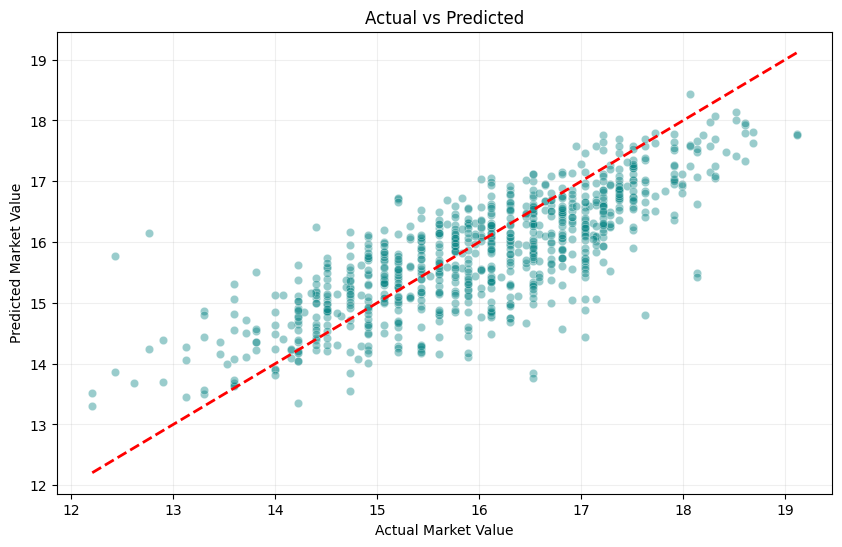

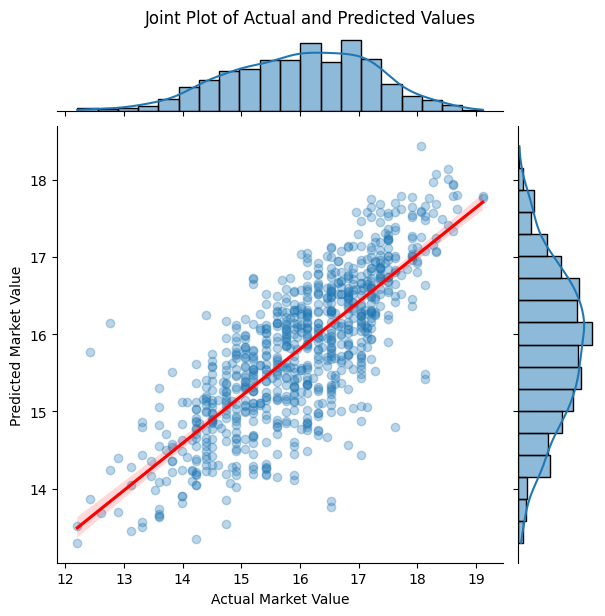

In [24]:
predict_and_plot(best_clf, X_test, y_test)

In [28]:
pd.DataFrame(clf_predictions).describe()

,0
count,828.000000
mean,15.812135
std,0.954053
min,13.297557
25%,15.128702
50%,15.843384
75%,16.514962
max,18.434928


In [27]:
pd.DataFrame(y_test).describe()

,Value
count,828.000000
mean,16.006155
std,1.219975
min,12.206078
25%,15.201805
50%,16.118096
75%,16.906553
max,19.113828


In [46]:
def plot_comparison_boxplot(y_pred, y_test, figsize=(10, 6)):
    df = pd.DataFrame({
        'Value': np.concatenate([y_pred, y_test]),
        'Type': ['Predictions'] * len(y_pred) + ['Actual'] * len(y_test)
    })

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df,
        x='Value',
        y='Type',
        ax=ax,
        hue='Type',
        palette={'Predictions': 'rebeccapurple', 'Actual': 'seagreen'},
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "red",
            "markeredgecolor": "none",
            "alpha": 0.5,
        },
        linewidth=1.5,
        legend=False,
    )

    metrics = {
        'Actual': {'val': np.array(y_test), 'color': 'seagreen'},
        'Predictions': {'val': np.array(y_pred), 'color': 'rebeccapurple'}
    }

    for i, (label, info) in enumerate(metrics.items()):
        d_mean = info['val'].mean()
        ax.axvline(d_mean, color=info['color'], linestyle="--", linewidth=2, 
                   label=f"{label} Mean: {d_mean:.2f}")

    ax.set_title("Actual vs Prediction Distribution Comparison", fontsize=14, pad=15)
    ax.set_xlabel("Value")
    ax.set_ylabel("")
    ax.legend(fontsize=9, loc="upper right")
    
    plt.tight_layout()
    plt.show()

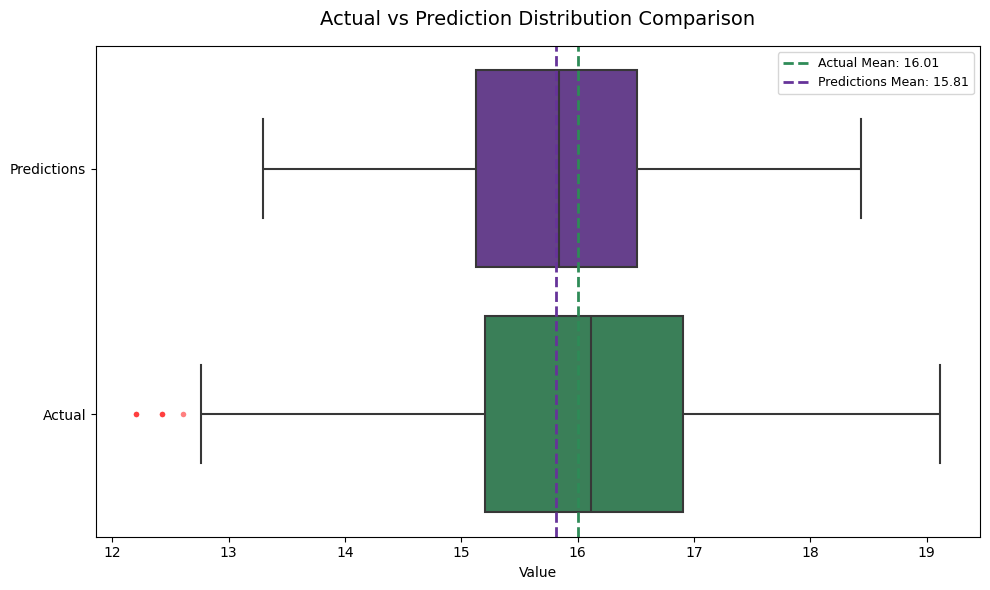

In [47]:
plot_comparison_boxplot(clf_predictions, y_test)

In [48]:
def plot_distribution_compare(y_pred, y_test):
    plt.figure(figsize=(10, 6))
    
    sns.kdeplot(y_test, label='Actual (y_test)', fill=True, alpha=0.3)
    sns.kdeplot(y_pred, label='Predicted (y_pred)', fill=True, alpha=0.3)
    
    plt.xlabel('Market Value')
    plt.title('Comparison of Distributions: Actual vs Predicted')
    plt.legend()
    plt.show()

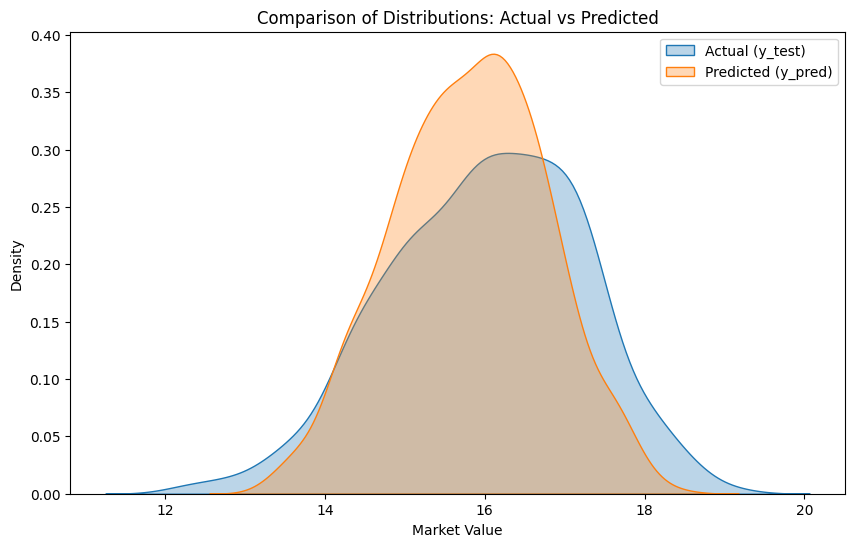

In [49]:
plot_distribution_compare(clf_predictions, y_test)

In [73]:
help(xgb.plot_importance)

Help on function plot_importance in module xgboost.plotting:

plot_importance(booster: Union[xgboost.sklearn.XGBModel, xgboost.core.Booster, dict], *, ax: Optional[Any] = None, height: float = 0.2, xlim: Optional[tuple] = None, ylim: Optional[tuple] = None, title: str = 'Feature importance', xlabel: str = 'Importance score', ylabel: str = 'Features', fmap: Union[str, os.PathLike] = '', importance_type: str = 'weight', max_num_features: Optional[int] = None, grid: bool = True, show_values: bool = True, values_format: str = '{v}', **kwargs: Any) -> Any
    Plot importance based on fitted trees.
    
    Parameters
    ----------
    booster :
        Booster or XGBModel instance, or dict taken by Booster.get_fscore()
    ax : matplotlib Axes
        Target axes instance. If None, new figure and axes will be created.
    grid :
        Turn the axes grids on or off.  Default is True (On).
    importance_type :
        How the importance is calculated: either "weight", "gain", or "cover"
 

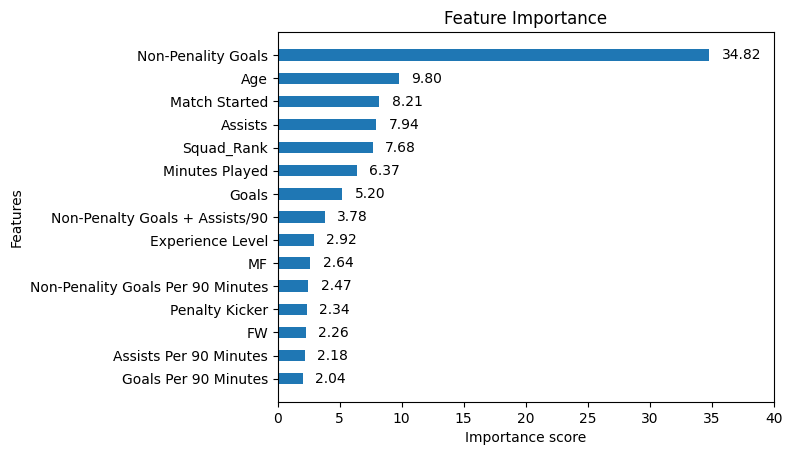

In [93]:
xgb.plot_importance(XGBmodel, importance_type='gain', height=0.5, values_format="{v:.2f}", xlim=(0, 40), grid=False)
plt.title('Feature Importance')
plt.show()

In [94]:
help(RandomForestRegressor)

Help on class RandomForestRegressor in module sklearn.ensemble._forest:

class RandomForestRegressor(ForestRegressor)
 |  RandomForestRegressor(n_estimators=100, *, criterion='squared_error', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |  
 |  A random forest regressor.
 |  
 |  A random forest is a meta estimator that fits a number of decision tree
 |  regressors on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
 |  The sub-sample size is controlled with the `max_samples` parameter if
 |  `bootstrap

In [95]:
def plot_rf_fi(model):
    feature_names = X_train.columns
    importances = best_clf.feature_importances_

    df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df = df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(x='Importance', y='Feature', hue='Feature', legend=False, data=df, palette='viridis')

    for p in ax.patches:
        width = p.get_width() 
        ax.text(width + 0.005,
                p.get_y() + p.get_height()/2,
                f'{width:.2f}',
                va='center')

    plt.title('Feature Importances', fontsize=15)
    plt.xlabel('Importance Score')
    plt.ylabel('Features')

    plt.xlim(0, df['Importance'].max() * 1.1) 
    plt.tight_layout()
    plt.show()

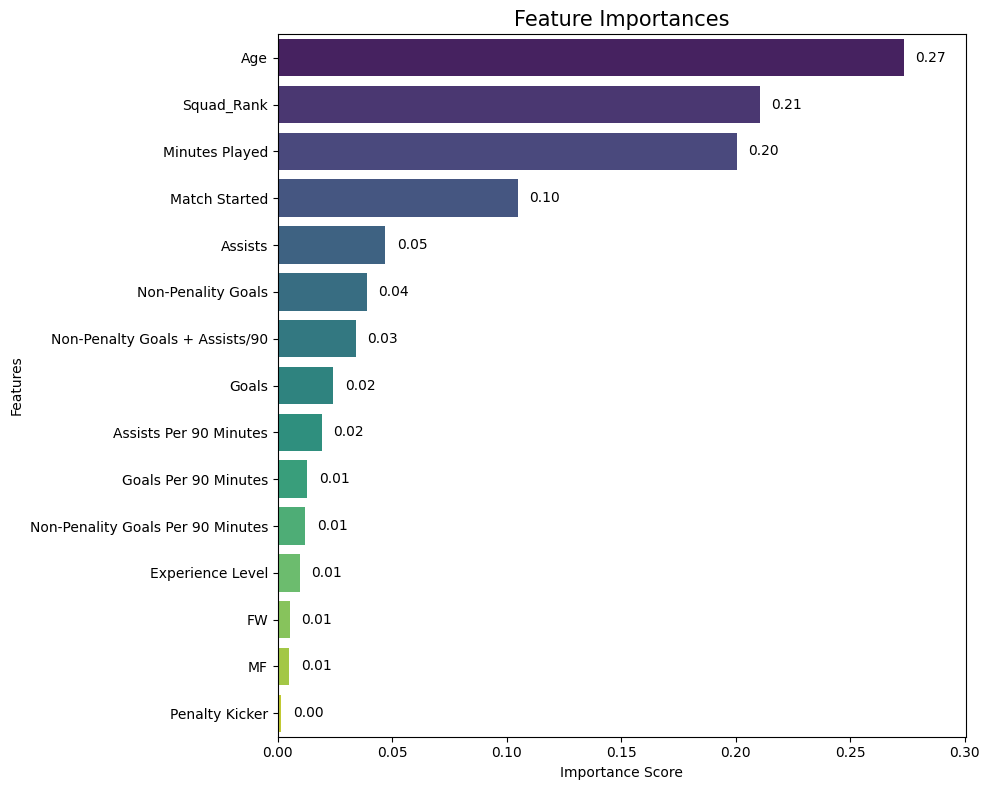

In [96]:
plot_rf_fi(best_clf)